In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import imageio
import os
from scipy.stats import mode
import skimage as ski
import time as tt
from mpl_toolkits.mplot3d import Axes3D
import csv
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import math
from scipy.optimize import curve_fit

In [2]:
# =============================================================================
# Model Parameters
# =============================================================================
N = 10000      # Number of agents
L = 100       # Number of different products
U = 100       # Number of product units each agent starts with
M = 300       # Memory length of each agent
t_max = 1000  # Total number of trade iterations
w = round(np.sqrt(N))  # For 2D simulation, sqrt(N) should be an integer

Default_cond = (t_max, N, L, U, M, 0, w)

In [3]:
# =============================================================================
# Functions for Agent Behavior
# =============================================================================

def AskN(i, I, T, c):
    """
    Ask function for NEED: Agent i chooses a product it needs if its inventory is <= 0.
    
    Parameters:
        i (int): Agent index.
        I (np.array): Inventory matrix.
        T (np.array): Memory matrix.
        c (str): Indicator variable (unused input here).
        
    Returns:
        prod_i_want (int): The product the agent wants (or -1 if none needed).
        c (str): Indicator ("N" for need, "H" otherwise).
    """
    need_i = np.where(I[i, :] <= 0)[0]
    if need_i.size > 0:
        prod_i_want = np.random.choice(need_i)
        c = "N"
    else:
        prod_i_want = -1
        c = "H"
    return prod_i_want, c


def AskG(i, I, T, c):
    """
    Ask function for GREED: Agent i chooses a product based on its memory or randomly.
    
    Parameters:
        i (int): Agent index.
        I (np.array): Inventory matrix.
        T (np.array): Memory matrix.
        c (str): Indicator variable (unused input here).
        
    Returns:
        prod_i_want (int): The product chosen.
        c (str): Always "G" for greed.
    """
    if len(T[i][T[i] != -1]) == 0:
        prod_i_want = np.random.randint(0, L)
    else:
        prod_i_want = np.random.choice(T[i][T[i] != -1])
    c = "G"
    return prod_i_want, c


def Ask(Start_cond, N_ij, I, T):
    """
    Combined Ask function: Agent i prioritizes need (inventory zero) over greed.
    
    Parameters:
        i (int): Agent index.
        I (np.array): Inventory matrix.
        T (np.array): Memory matrix.
        c (str): Indicator variable (unused input here).
        
    Returns:
        prod_i_want (int): The product chosen.
        c (str): "N" if based on need, "G" if based on greed.
    """
    t_max, N, L, U, M, sigma, w = Start_cond
    mask = ~np.any(I == 0, axis=1) #True if no need, False if need
    
    random_indices_for_Greed = np.random.randint(0, M, size=len(T))
    T_choices = T[np.arange(len(T)), random_indices_for_Greed]
    
    row, col = np.where(I == 0)
    Agent_needs ,ind,mult = np.unique(row, return_index=True,return_counts=True)
    mult = mult-1
    random_values = (np.random.rand(len(mult)) * (mult+1)).astype(int)
    ind = ind+random_values
    L_choises_need = np.array(col)[ind]
    I_choices = -np.ones(N)
    I_choices[Agent_needs] = L_choises_need
    
    result = np.where(mask, T_choices, I_choices)
    #temp change
    return result, mask

# =============================================================================
# Functions for Trade and Memory Updates
# =============================================================================

def Trade(Start_cond, N_ij, N_ij_want, I, T, frac, trade, Agents_score, demand):
    """
    Performs a trade between agents i and j exchanging products.
    """
    t_max, N, L, U, M, sigma, w = Start_cond
    half = N // 2
    N_ij_want = np.array(N_ij_want, dtype=np.int64)
    frac_A = frac[:half]
    frac_B = frac[half:]
    # Split into two halves:
    A = N_ij[:half]
    B = N_ij[half:]
    
    # Determine the columns corresponding to the 'wants'
    cols_A = N_ij_want[A]
    cols_B = N_ij_want[B]
    
    # Build the condition vector:
    # Trade is allowed only if for each pair, both:
    #   I[b, N_ij_want[a]] != 0  and  I[a, N_ij_want[b]] != 0.
    cond = (I[B, cols_A] != 0) & (I[A, cols_B] != 0)

    # Log the failed trades
    failed_trade = np.concatenate((cols_A[~cond],cols_B[~cond]))
    histogram_failed_trade = np.bincount(failed_trade, minlength=L)
    
    # Now extract only the pairs where condition is met:
    A_valid = A[cond]
    B_valid = B[cond]
    cols_A_valid = N_ij_want[A_valid]
    cols_B_valid = N_ij_want[B_valid]
    
    # Apply the trade updates:
    I[A_valid, cols_A_valid] += 1
    I[B_valid, cols_A_valid] -= 1
    I[A_valid, cols_B_valid] -= 1
    I[B_valid, cols_B_valid] += 1
    frac_A_valid = frac_A[cond]
    frac_B_valid = frac_B[cond]
        
    # Update agent scores based on previous demand (note: uses trade-1 index)
    Agents_score[trade, A_valid] = demand[trade - 1, cols_A_valid] - demand[trade - 1, cols_B_valid]
    Agents_score[trade, B_valid] = demand[trade - 1, cols_B_valid] - demand[trade - 1, cols_A_valid]
    
    # If desired, combine the valid frac parts:
    frac_valid = np.concatenate([frac_A_valid, frac_B_valid])
    return frac_valid, histogram_failed_trade


def MemoryUpdate(Start_cond, N_ij, N_ij_want, I, T):
    """
    Updates the memory of agents i and j with the traded products.
    """
    t_max, N, L, U, M, sigma, w = Start_cond
    memory_index = np.random.randint(0, M, N)
    half = N // 2

    # Split into two halves:
    A = N_ij[:half]
    B = N_ij[half:]
    
    # Determine the columns corresponding to the 'wants'
    cols_A = N_ij_want[A]
    cols_B = N_ij_want[B]
    
    T[A, memory_index[0]] = cols_B
    T[B, memory_index[1]] = cols_A


def Pro_Consumption(Start_cond, N_ij, I, T):
    """
    Handles production and consumption events for agent i based on a probability sigma.
    """
    t_max, N, L, U, M, sigma, w = Start_cond

    rand_vals = np.random.rand(len(N_ij))  # Uniform random values in [0,1)
    mask = rand_vals <= sigma      # Boolean mask for which agents will act
    random_indices = np.random.randint(0, M, len(T[mask]))
    choices = T[mask][np.arange(len(T[mask])), random_indices]
    I[mask, choices] += 1 #Update value

    I_masked = I[mask] != 0
    random_values = np.random.rand(*I_masked.shape)
    masked_random = np.where(I_masked, random_values, np.inf)
    sorted_indices = np.argsort(masked_random, axis=1)
    result = sorted_indices[:, :1].T[0]
    I[mask, result] -= 1 #Update value


# =============================================================================
# Functions for Selecting Agents and News
# =============================================================================

def pick_agents1D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents randomly (1D).
    """
    return np.random.choice(N, 2, replace=False)


def pick_agents2D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents from a 2D grid with periodic boundaries.
    """
    x, y = np.random.randint(0, w, 2)
    i = Agent_grid[x, y]
    
    while True:
        dx, dy = np.random.choice(range(-cons, cons + 1), 2)
        x2 = (x + dx) % w
        y2 = (y + dy) % w
        j = Agent_grid[x2, y2]
        if i != j:
            return i, j


def weighted_random(M):
    """
    Returns a weighted random integer based on an exponential decay.
    Adjust the decay parameter (L/9) as needed.
    """
    weights = np.exp(-np.arange(1, L + 1) / (L / 9))
    weights /= weights.sum()
    return np.random.choice(np.arange(1, L + 1), p=weights)


def news1D(Amount, sigma, L, Agent_grid, I, T):
    """
    Placeholder for news effect in 1D.
    """
    x = Amount  # Currently does nothing


def news2D(Amount, sigma, L, Agent_grid, I, T):
    """
    Updates the memory of agents in a 2D grid based on weighted news.
    """
    if np.sqrt(np.random.randn() ** 2) <= sigma:
        prod_news = np.random.randint(0, L)
        news_weight = weighted_random(M)

        # Select a random coordinate within the grid
        x1, y1 = np.random.randint(0, round(np.sqrt(Amount)), 2)
        # Define neighbor coordinates with wrapping
        x0, y0 = ((x1 - 1) % w, (y1 - 1) % w)
        x2, y2 = ((x1 + 1) % w, (y1 + 1) % w)
        
        # Collect agents in a 3x3 neighborhood
        a0 = Agent_grid[x0, y0]
        b0 = Agent_grid[x0, y1]
        c0 = Agent_grid[x0, y2]
        a1 = Agent_grid[x1, y0]
        b1 = Agent_grid[x1, y1]
        c1 = Agent_grid[x1, y2]
        a2 = Agent_grid[x2, y0]
        b2 = Agent_grid[x2, y1]
        c2 = Agent_grid[x2, y2]
        neighborhood = [a0, b0, c0, a1, b1, c1, a2, b2, c2]

        for ag in neighborhood:
            for _ in range(news_weight):
                memory_index = np.random.randint(0, M)
                T[ag, memory_index] = prod_news


# =============================================================================
# Utility Functions
# =============================================================================

def random_min_index(lst):
    """
    Chooses a random index among the indices corresponding to the minimum value in a list.
    """
    min_value = min(lst)
    min_indices = [i for i, val in enumerate(lst) if val == min_value]
    return random.choice(min_indices)


def most_prominent(arr):
    """
    Counts the most prominent (frequent) element in each row of arr, ignoring -1.
    Returns a numpy array of the most frequent elements per row.
    """
    result = []
    for row in arr:
        filtered_row = [x for x in row if x != -1]
        if not filtered_row:
            result.append(0)
        else:
            counter = Counter(filtered_row)
            max_count = max(counter.values())
            # Get the first candidate with the maximum count
            candidates = [num for num in filtered_row if counter[num] == max_count]
            result.append(candidates[0])
    return np.array(result)


def Hurst(L_list, T_window):
    """
    Computes an estimate for the Hurst exponent based on a given time window.
    
    Parameters:
        L_list (list or np.array): A list of values.
        T_window (int): The window size for calculation.
        
    Returns:
        float: The mean squared difference over the window.
    """
    Temp = []
    for i, k in enumerate(L_list[:-T_window]):
        c = (np.log(L_list[i + T_window]) - np.log(L_list[i])) ** 2
        Temp.append(c)
    return np.mean(Temp)


def count_elements_in_chunks(data, t_max, L):
    """
    Counts occurrences of each product in chunks of the timeline.
    
    Parameters:
        data (np.array): 1D array with trade data.
        t_max (int): Total number of iterations.
        L (int): Number of products.
        
    Returns:
        np.array: A 2D array with counts per chunk and a time indicator.
    """
    num_chunks = t_max // 50
    counts = np.full((num_chunks, L + 1), np.nan, dtype=float)
    
    for i in range(num_chunks):
        chunk = data[i * 100 : (i + 1) * 100]
        for p in range(L):
            counts[i, p] = (chunk == p).sum()
        counts[i, p + 1] = i * 50
    return counts


def Talk(i, j, I, T):
    """
    Allows agents i and j to discuss a product.
    If both discuss the same product, update their memory.
    """
    if len(T[i][T[i] != -1]) == 0:
        prod_i_talk = np.random.randint(0, L)
    else:
        prod_i_talk = np.random.choice(T[i][T[i] != -1])
    
    if len(T[j][T[j] != -1]) == 0:
        prod_j_talk = np.random.randint(0, L)
    else:
        prod_j_talk = np.random.choice(T[j][T[j] != -1])
    
    if prod_i_talk == prod_j_talk:
        MemoryUpdate(i, j, prod_i_talk, prod_j_talk, I, T)

In [4]:
# =============================================================================
# Main Simulation Function
# =============================================================================

def Trade_Sim(Start_cond):
    """
    Main simulation function for trade among agents.
    
    Parameters:
        Start_cond (tuple): (t_max, N, L, U, M,) The important starting conditions .
        D (int): Dimension flag (2 for 2D, else 1D).
        Type (int): Trade type indicator:
                    2 -> Only Greed,
                    3 -> Only Need,
                    Other -> Normal (both).
                    
    Returns:
        tuple: (I_history, T_history, Frac, Trade_history, Demand_list, Agents_score)
    """
    t_max, N, L, U, M, sigma, w = Start_cond

    # Initialize inventory for each agent
    I = np.zeros((N, L), dtype=int)
    # Create a shuffled array of products to distribute equally among agents

    products = np.tile(np.arange(L), N // L)
    products = np.tile(products, U)

    '''
    products = np.tile(np.arange(L), U // L)
    products = np.tile(products, N
    '''
    np.random.shuffle(products)
    for idx, prod in enumerate(products):
        agent = idx % N
        I[agent, prod] += 1

    # Initialize memory for each agent (-1 indicates empty memory)
    assert (N * M) % L == 0, "N * M must be divisible by L for equal distribution"
    repeats_per_item = N * M // L
    values = np.tile(np.arange(L), repeats_per_item)
    np.random.shuffle(values)
    T = values.reshape((N, M))


    # Prepare histories and tracking arrays
    I_history = np.empty((t_max, N, L), dtype=int)
    T_history = np.empty((t_max, N, M), dtype=int)
    Demand_list = np.empty((t_max, L))
    Trade_history = -np.ones(t_max * 2, dtype=int)
    Agents_score = np.zeros((t_max, N))
    Failed_trades = np.ones((t_max,L))
    Trade_index = 0 # Pointer for filling Trade_history

    # Fraction counters: each row is [time_chunk, fraction_greed, fraction_need]
    Frac = np.empty((t_max, 3))

    Asking = Ask

    # Main simulation loop
    for trade in range(t_max):
        N_ij = np.arange(N)       # array of 0 to N-1
        np.random.shuffle(N_ij)   # Agent pairs, Agent 0 trades with 50

        
        # Optionally include discussion (currently commented out)
        # if np.sqrt(np.random.randn()**2) <= sigma and sigma != 0:
        #     Talk(i, j, I, T)
        
        # Production/Consumption step for both agents
        Pro_Consumption(Start_cond, N_ij, I, T)
        # Optionally, news can be incorporated:
        # news(N, sigma / 100, L, Agent_grid, I, T)
        
        # Agents decide what product they want based on their strategy
        N_ij_want, c = Asking(Start_cond, N_ij, I, T)

        # Process the trade if both agents have valid choices and available inventory
        cnew, hft = Trade(Start_cond, N_ij,N_ij_want, I, T, c, trade, Agents_score, Demand_list)

        Failed_trades[trade] = hft
        Frac[trade] = trade, np.nanmean(cnew), 1 - np.nanmean(cnew)

        #Updating demand
        Demand_list[trade, :] = np.sum(T[..., None] == np.arange(L), axis=(0, 1)) / (N * M)
        

        # Cumulative agent score update
        Agents_score[trade, :] += Agents_score[trade - 1, :]
        
        # Update agents' memories based on the trade (or attempted trade)
        MemoryUpdate(Start_cond, N_ij, N_ij_want, I, T)

        # Save current state of inventory and memory
        I_history[trade] = I.copy()
        T_history[trade] = T.copy()

    return I_history, T_history, Frac, Demand_list, Agents_score, Failed_trades

In [5]:
import yfinance as yf

# 2. Download 5 years of daily BTC-USD data
btc = yf.Ticker("BTC-USD")
hist = btc.history(period="5y")    # you can also use start="2019-05-08", end="2024-05-08"

# 3. Save to CSV
hist.to_csv("BTC_USD_last5years.csv")

print("Saved BTC_USD_last5years.csv with", len(hist), "rows of data.")

Saved BTC_USD_last5years.csv with 1827 rows of data.


In [2]:
print(hist)

                                   Open          High           Low  \
Date                                                                  
2020-05-07 00:00:00+00:00   9261.895508   9992.664062   9138.322266   
2020-05-08 00:00:00+00:00   9936.162109   9996.743164   9767.172852   
2020-05-09 00:00:00+00:00   9840.906250   9913.863281   9580.644531   
2020-05-10 00:00:00+00:00   9591.168945   9595.581055   8395.107422   
2020-05-11 00:00:00+00:00   8755.535156   9033.470703   8374.323242   
...                                 ...           ...           ...   
2025-05-03 00:00:00+00:00  96904.632812  96943.882812  95821.289062   
2025-05-04 00:00:00+00:00  95877.187500  96318.921875  94173.429688   
2025-05-05 00:00:00+00:00  94319.562500  95193.187500  93566.265625   
2025-05-06 00:00:00+00:00  94748.382812  96889.179688  93399.859375   
2025-05-07 00:00:00+00:00  96829.015625  97583.914062  95866.679688   

                                  Close       Volume  Dividends  Stock Split

In [6]:
import pandas as pd
import numpy as np

def load_btc_time_series(csv_path):
    """
    Load BTC-USD historical data and return NumPy arrays of dates and close prices.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file (e.g. 'BTC_USD_last5years.csv').

    Returns
    -------
    dates : numpy.ndarray of datetime64[ns]
        Array of trading dates.
    prices : numpy.ndarray of float
        Array of corresponding closing prices.
    """
    # Read CSV and parse the Date column as datetime
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    
    # Extract NumPy arrays
    dates = df['Date'].to_numpy()      # dtype datetime64[ns]
    prices = df['Close'].to_numpy()    # dtype float64
    
    return dates, prices

if __name__ == "__main__":
    dates, prices = load_btc_time_series("BTC_USD_last5years.csv")
    print("First 5 dates:", dates[:5])
    print("First 5 prices:", prices[:5])
    print("Array shapes:", dates.shape, prices.shape)


First 5 dates: [Timestamp('2020-06-04 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-05 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-06 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-07 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-08 00:00:00+0000', tz='UTC')]
First 5 prices: [9800.63671875 9665.53320312 9653.6796875  9758.85253906 9771.48925781]
Array shapes: (1827,) (1827,)


In [7]:
def load_gold_price_series(ticker="GC=F", period="5y"):
    """
    Download gold price data and return dates, prices as NumPy arrays,
    plus a Python list of prices.
    
    Parameters
    ----------
    ticker : str
        Yahoo Finance ticker for gold (default "GC=F" for COMEX futures).
    period : str
        Data period to download (default "5y" for five years).
    
    Returns
    -------
    dates : numpy.ndarray (datetime64[ns])
        Array of trading dates.
    prices : numpy.ndarray (float64)
        Array of corresponding closing prices.
    price_list : list of float
        Same prices as a Python list.
    """
    # Fetch the data
    gold = yf.Ticker(ticker)
    hist = gold.history(period=period)
    
    # Extract as NumPy arrays
    dates = hist.index.to_numpy()          # dtype: datetime64[ns]
    prices = hist['Close'].to_numpy()      # dtype: float64
    
    # And make a plain Python list of prices
    price_list = prices.tolist()
    
    return dates, prices, price_list

if __name__ == "__main__":
    dates, prices, price_list = load_gold_price_series()
    print("First 5 dates:", dates[:5])
    print("First 5 prices:", prices[:5])
    print("First 5 prices (list):", price_list[:5])
    print("Total points:", len(prices))

First 5 dates: [Timestamp('2020-06-04 00:00:00-0400', tz='America/New_York')
 Timestamp('2020-06-05 00:00:00-0400', tz='America/New_York')
 Timestamp('2020-06-08 00:00:00-0400', tz='America/New_York')
 Timestamp('2020-06-09 00:00:00-0400', tz='America/New_York')
 Timestamp('2020-06-10 00:00:00-0400', tz='America/New_York')]
First 5 prices: [1718.90002441 1676.19995117 1698.30004883 1714.69995117 1713.30004883]
First 5 prices (list): [1718.9000244140625, 1676.199951171875, 1698.300048828125, 1714.699951171875, 1713.300048828125]
Total points: 1258


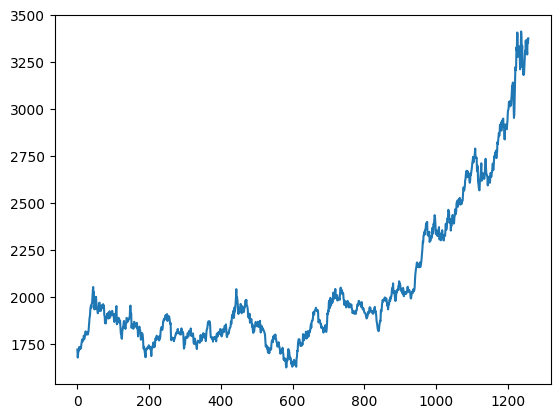

In [8]:
plt.plot(prices)

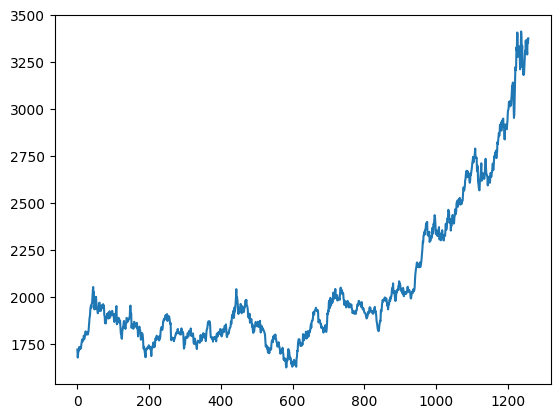

In [9]:
plt.plot(prices)

In [10]:
def Hurst(L_list, T_window):
    """
    Computes an estimate for the Hurst exponent based on a given time window.
    
    Parameters:
        L_list (list or np.array): A list of values.
        T_window (int): The window size for calculation.
        
    Returns:
        float: The mean squared difference over the window.
    """
    Temp = []
    for i, k in enumerate(L_list[:-T_window]):
        c = (np.log(L_list[i + T_window]) - np.log(L_list[i])) ** 2
        Temp.append(c)
    return np.mean(Temp)

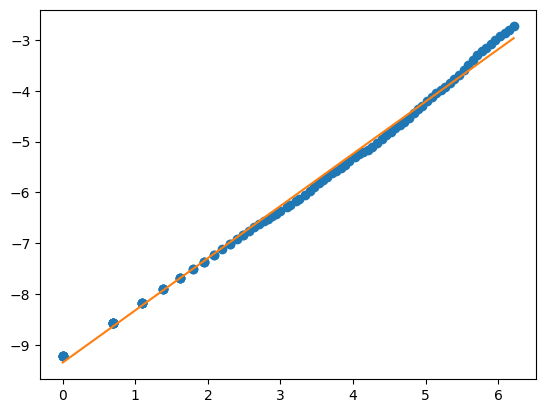

0.5130362824405805


In [11]:
start = np.log10(1)  
end = np.log10(500)
TL = np.round( np.logspace(start, end, num=100),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(prices,p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o')
plt.plot(x,y)
plt.show()
print(slope/2)

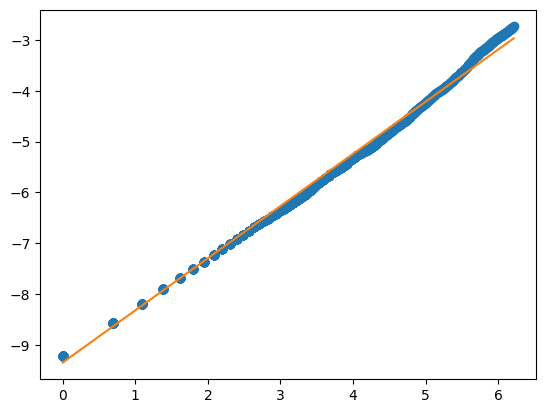

0.512726302758218


In [12]:
start = np.log(1)  
end = np.log(500)
TL = np.round( np.logspace(start, end, num=1000, base = np.exp(1)),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(prices,p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o')
plt.plot(x,y)
plt.show()
print(slope/2)

In [13]:
def load_doge_price_series(ticker="DOGE-USD", period="5y"):
    """
    Download Dogecoin price data and return dates, prices as NumPy arrays,
    plus a Python list of prices.
    
    Parameters
    ----------
    ticker : str
        Yahoo Finance ticker for Dogecoin (default "DOGE-USD").
    period : str
        Data period to download (default "5y" for five years).
    
    Returns
    -------
    dates : numpy.ndarray of datetime64[ns]
        Array of trading dates.
    prices : numpy.ndarray of float64
        Array of corresponding closing prices.
    price_list : list of float
        Same prices as a Python list.
    """
    # Fetch the data
    doge = yf.Ticker(ticker)
    hist = doge.history(period=period)

    # Extract as NumPy arrays
    dates = hist.index.to_numpy()          # dtype: datetime64[ns]
    prices = hist['Close'].to_numpy()      # dtype: float64

    # Convert prices to a plain Python list
    price_list = prices.tolist()

    return dates, prices, price_list

if __name__ == "__main__":
    dates, prices_doge, price_list = load_doge_price_series()
    print("First 5 dates:", dates[:5])
    print("First 5 prices:", prices[:5])
    print("First 5 prices (list):", price_list[:5])
    print("Total data points:", len(prices))

First 5 dates: [Timestamp('2020-06-04 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-05 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-06 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-07 00:00:00+0000', tz='UTC')
 Timestamp('2020-06-08 00:00:00+0000', tz='UTC')]
First 5 prices: [1718.90002441 1676.19995117 1698.30004883 1714.69995117 1713.30004883]
First 5 prices (list): [0.0026310000102967024, 0.002595999976620078, 0.0025869999080896378, 0.002606000052765012, 0.0025839998852461576]
Total data points: 1258


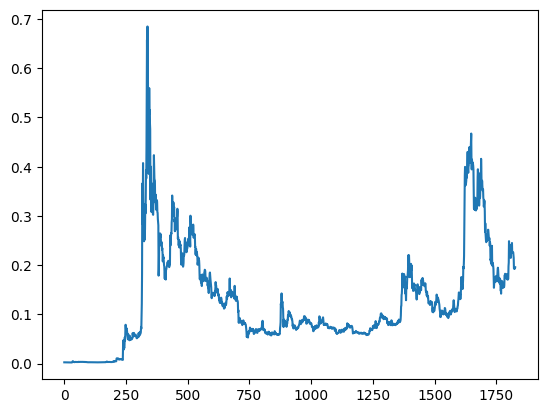

In [14]:
plt.plot(prices_doge)

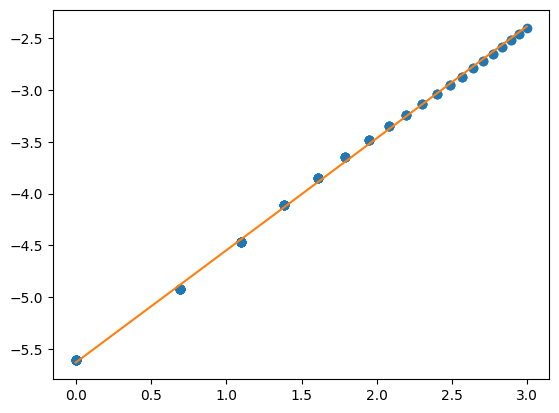

0.5414216616130534


In [15]:
start = np.log(1)  
end = np.log(20)
TL = np.round( np.logspace(start, end, num=100, base = np.exp(1)),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(prices_doge[250:],p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o')
plt.plot(x,y)
plt.show()
print(slope/2)

First 5 dates: [Timestamp('2020-06-04 00:00:00+0200', tz='Europe/Copenhagen')
 Timestamp('2020-06-08 00:00:00+0200', tz='Europe/Copenhagen')
 Timestamp('2020-06-09 00:00:00+0200', tz='Europe/Copenhagen')
 Timestamp('2020-06-10 00:00:00+0200', tz='Europe/Copenhagen')
 Timestamp('2020-06-11 00:00:00+0200', tz='Europe/Copenhagen')]
First 5 Novo prices: [197.81768799 195.51480103 197.24197388 201.17990112 200.67326355]
Total data points: 1255


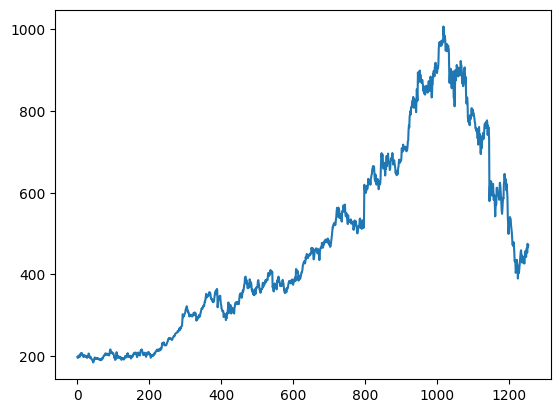

In [16]:
def load_novo_price_series(ticker="NOVO-B.CO", period="5y"):
    """
    Download Novo Nordisk B-share price data and return dates,
    plus a NumPy array of closing prices named prices_novo,
    and a Python list of those prices.

    Parameters
    ----------
    ticker : str
        Yahoo Finance ticker for Novo Nordisk B (default "NOVO-B.CO").
    period : str
        Data period to download (default "5y" for five years).

    Returns
    -------
    dates_novo : numpy.ndarray of datetime64[ns]
        Array of trading dates.
    prices_novo : numpy.ndarray of float64
        Array of corresponding closing prices.
    price_list_novo : list of float
        Same prices as a Python list.
    """
    # Fetch the data
    novo = yf.Ticker(ticker)
    hist = novo.history(period=period)

    # Extract dates and closing prices
    dates_novo = hist.index.to_numpy()           # dtype: datetime64[ns]
    prices_novo = hist['Close'].to_numpy()       # dtype: float64

    # Plain Python list if you need it
    price_list_novo = prices_novo.tolist()

    return dates_novo, prices_novo, price_list_novo

if __name__ == "__main__":
    dates_novo, prices_novo, price_list_novo = load_novo_price_series()
    print("First 5 dates:", dates_novo[:5])
    print("First 5 Novo prices:", prices_novo[:5])
    print("Total data points:", len(prices_novo))
plt.plot(prices_novo)

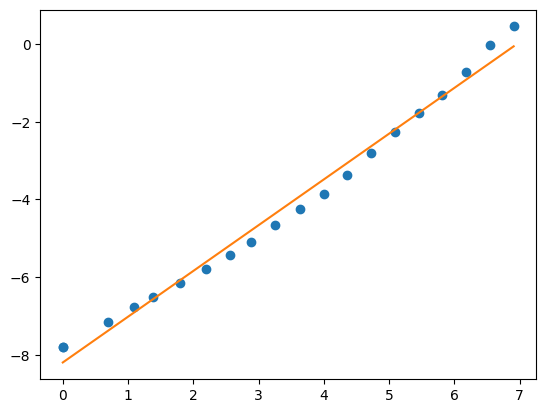

0.5884289583902046


In [17]:
start = np.log(1)  
end = np.log(1000)
TL = np.round( np.logspace(start, end, num=20, base = np.exp(1)),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(prices_novo,p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o')
plt.plot(x,y)
plt.show()
print(slope/2)

BRK-B: using Adj Close
^GSPC: using Adj Close
GC=F: using Adj Close
^DJI: using Adj Close
SI=F: using Adj Close
CL=F: using Adj Close
NOVO-B.CO: using Adj Close
BTC-USD: using Adj Close
MAERSK-B.CO: using Adj Close
ETH-USD: using Adj Close
^IXIC: using Adj Close
EEM: using Adj Close


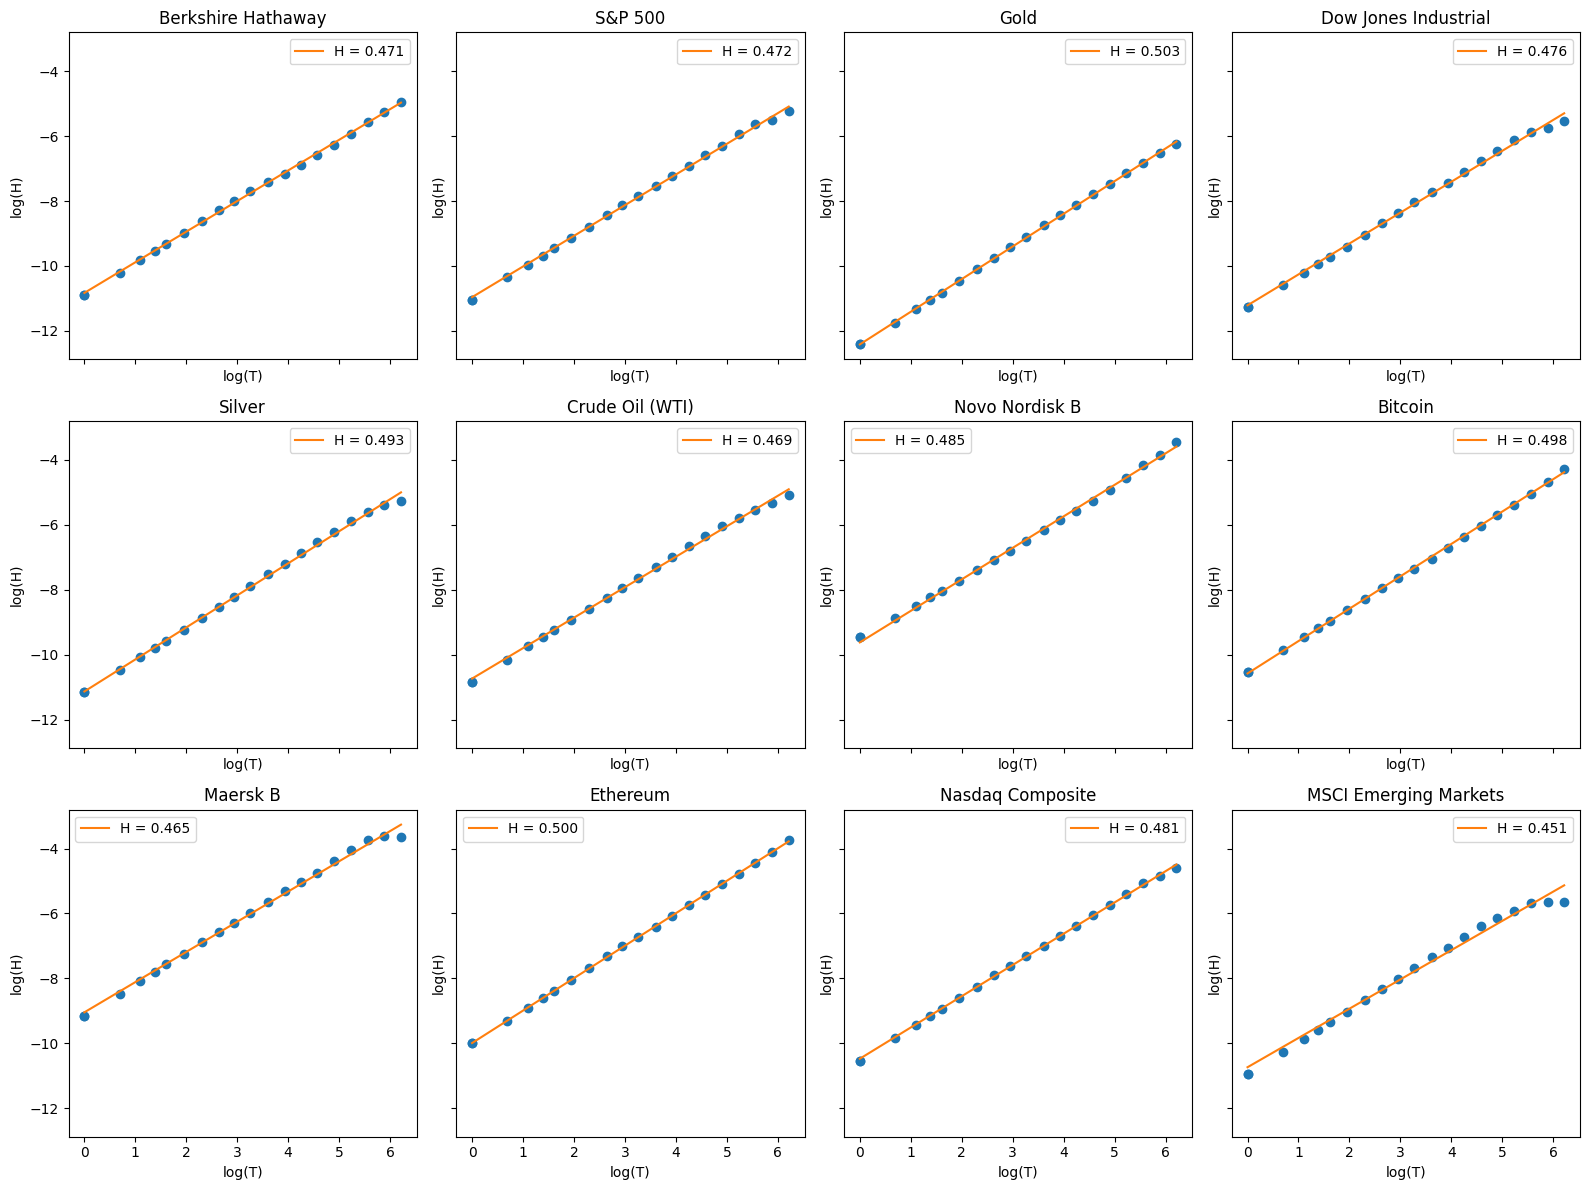

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Expanded Tickers
tickers = {
    # Old–greed driven (left half columns)
    'Berkshire Hathaway':        'BRK-B',
    'S&P 500':                   '^GSPC',
    'Gold':                      'GC=F',
    'Dow Jones Industrial':      '^DJI',
    'Silver':                    'SI=F',
    'Crude Oil (WTI)':           'CL=F',

    # Newer need–driven (right half columns)
    'Novo Nordisk B':            'NOVO-B.CO',
    'Bitcoin':                   'BTC-USD',
    'Maersk B':                  'MAERSK-B.CO',
    'Ethereum':                  'ETH-USD',
    'Nasdaq Composite':          '^IXIC',
    'MSCI Emerging Markets':     'EEM',
    # (Optional) add U.S. 10-Year Yield if you like, e.g. '^TNX'
}

# 2. Download daily data for last 5 years (1825 days)
data = yf.download(
    tickers=list(tickers.values()),
    period='730d',
    interval='1h',
    auto_adjust=False,   # “Close” = actual settlement price
    progress=False
)

# 3. Build flat price DataFrame: preferring Adj Close per symbol
prices = pd.DataFrame(index=data.index)
for name, sym in tickers.items():
    if ('Adj Close', sym) in data.columns:
        prices[name] = data['Adj Close', sym]
        print(f"{sym}: using Adj Close")
    else:
        prices[name] = data['Close', sym]
        print(f"{sym}: using Close")

# 4. daily averages are just the daily series
daily_avg = prices.copy()

# 5. Hurst windowed estimator
def Hurst(series, window):
    diffs = (np.log(series[window:]) - np.log(series[:-window]))**2
    return diffs.mean()

# 6. Window sizes (1 ≤ T ≤ 1000, log-spaced)
start, end = np.log(1), np.log(500)
TL = np.round(np.logspace(start, end, num=20, base=np.e)).astype(int)

# 7. Compute Hurst exponents for each market
results = {}
for name in daily_avg.columns:
    series = daily_avg[name].dropna().values
    H_vals = np.array([Hurst(series, w) for w in TL])
    log_T, log_H = np.log(TL), np.log(H_vals)
    # Fit skipping the very small windows if noisy
    slope, intercept = np.polyfit(log_T[2:], log_H[2:], 1)
    results[name] = {
        'log_T': log_T,
        'log_H': log_H,
        'slope': slope,
        'intercept': intercept,
        'H': slope / 2
    }

# 8. Plot a 3×4 grid
n = len(results)
cols = 4
rows = int(np.ceil(n/cols))

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    x_fit = np.linspace(r['log_T'].min(), r['log_T'].max(), 100)
    y_fit = r['slope']*x_fit + r['intercept']
    ax.plot(r['log_T'], r['log_H'], 'o')
    ax.plot(x_fit, y_fit, '-', label=f"H = {r['H']:.3f}")
    ax.set_title(name)
    ax.set_xlabel('log(T)')
    ax.set_ylabel('log(H)')
    ax.legend()

# Turn off any unused subplots
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import yfinance as yf
import numpy as np

Data spans from 2022-07-08 07:00:00+00:00 to 2025-06-04 14:00:00+00:00
NumPy array shape: (6150, 1)


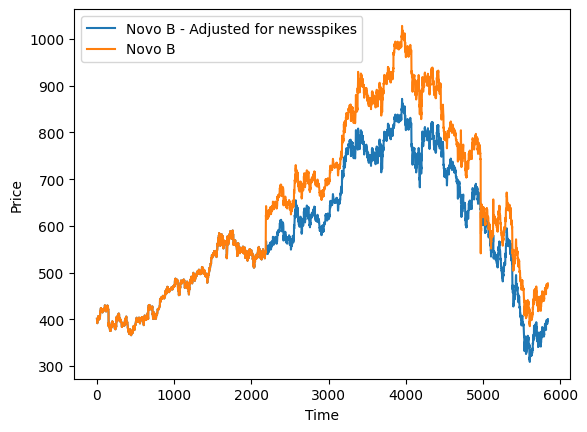

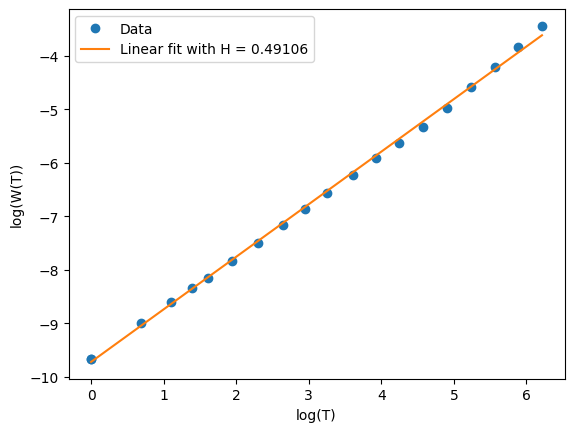

0.4910613106192196


In [99]:
# 1. Define the ticker
ticker = "NOVO-B.CO"    # Novo Nordisk B (Copenhagen Stock Exchange) :contentReference[oaicite:1]{index=1}

# 2. Download max-period history
data = yf.download(
    ticker,
    period="730d",       # up to 730 days back is supported for interval="1h"
    interval="1h",       # fetch 1-hour bars
    auto_adjust=False,   # ensure “Close” = actual settlement price
    progress=False
)

# 3. Extract adjusted close prices
prices = data["Adj Close"]   # split/dividend-adjusted closing price

# 4. Convert to NumPy array
price_novo = prices.values
price_novo2 = price_novo.copy()

price_novo_delta = (price_novo[1:] - price_novo[:-1])
price_novo_delta = np.insert(price_novo_delta, 0, 0)
mask = np.where(np.abs(price_novo_delta) > np.mean(np.abs(price_novo_delta)) + 6* np.std(np.abs(price_novo_delta)) )
for i, p in enumerate(mask[0]):
    price_novo[p:] = price_novo[p:] -  price_novo_delta[p]
# 5. (Optional) Get corresponding dates

dates = data.index.to_numpy()

# 6. Inspect
print("Data spans from", data.index.min(), "to", data.index.max())
print("NumPy array shape:", price_array.shape)
plt.plot(price_novo, label = "Novo B - Adjusted for newsspikes")
plt.plot(price_novo2, label = "Novo B")
plt.legend()
plt.ylabel("Price")
plt.xlabel("Time")
plt.show()
start = np.log(1)  
end = np.log(500)
TL = np.round( np.logspace(start, end, num=20, base = np.exp(1)),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(price_novo,p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o', label= "Data")
plt.plot(x,y, label=f"Linear fit with H = {round(slope/2,5)}")
plt.legend()
plt.xlabel("log(T)")
plt.ylabel("log(W(T))")
plt.show()
print(slope/2)

=== Backtest Metrics (20% reinvest, ±2% bands) ===
total_return   : 0.1658
num_trades     : 155.0000
win_rate       : 0.6258
approx_CAGR    : 0.0440


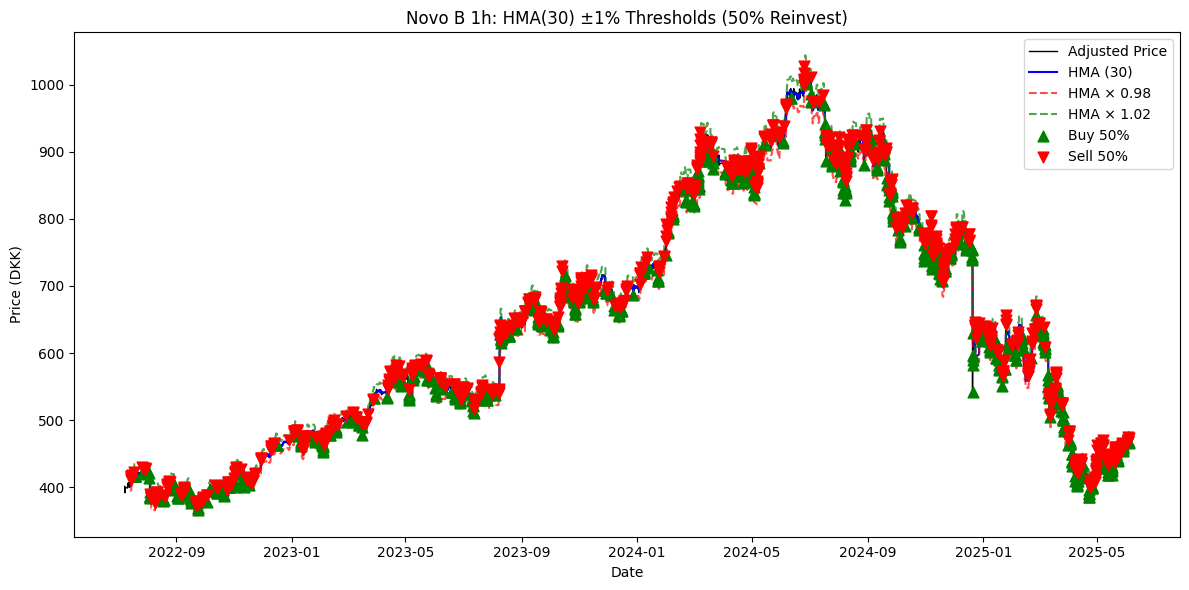

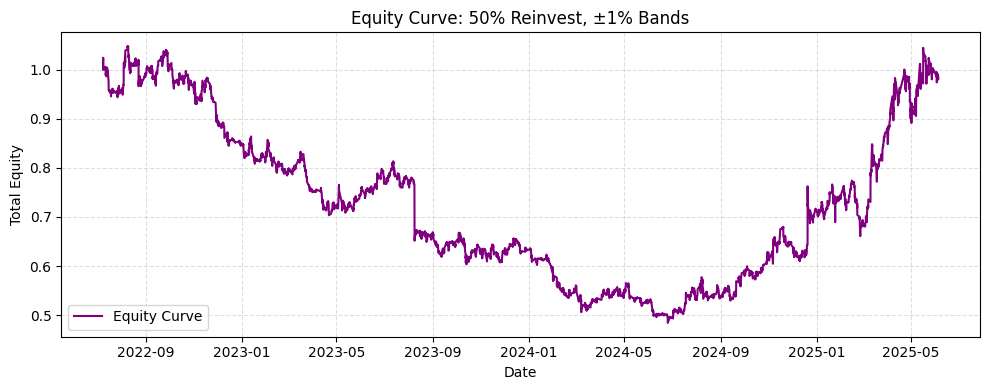

In [111]:
import numpy as np
import pandas as pd

# 1) HMA helper functions
def weighted_moving_average(series: np.ndarray, period: int) -> np.ndarray:
    """
    Compute a weighted moving average (WMA) of `series` with window `period`.
    WMA at time t = sum_{i=0..period-1} [ (period - i) * series[t - i] ] / sum_{i=1..period} i.
    Returns an array of the same length as `series`, with NaNs for the first (period-1) points.
    """
    if period < 1:
        raise ValueError("Period must be >= 1")
    w = np.arange(1, period + 1)
    w_sum = w.sum()
    out = np.full_like(series, fill_value=np.nan, dtype=float)

    for t in range(period - 1, len(series)):
        window = series[t - (period - 1) : t + 1]
        out[t] = (window * w).sum() / w_sum

    return out


def hull_moving_average(series: np.ndarray, length: int) -> np.ndarray:
    """
    Compute the Hull Moving Average (HMA) for a given series and lookback `length`.
    HMA(len) = WMA( 2 * WMA(series, len/2) - WMA(series, len), sqrt(len) )
    Both intermediate WMAs use integer periods (floor).
    Returns an array (float) of the same length, with NaNs in the first max-lag points.
    """
    if length < 1:
        raise ValueError("Length must be >= 1")
    half_len = int(np.floor(length / 2))
    sqrt_len = int(np.floor(np.sqrt(length)))

    wma_full = weighted_moving_average(series, length)
    wma_half = weighted_moving_average(series, half_len)
    diff = 2 * wma_half - wma_full
    hma = weighted_moving_average(diff, sqrt_len)
    return hma


# 2) Backtest function (20% reinvestment per signal, threshold adjustable)
def backtest_hma_threshold_partial(
    prices: np.ndarray,
    dates: np.ndarray,
    hma_length: int = 30,
    pct_threshold: float = 0.02,   # <-- now 2%
    invest_fraction: float = 0.20,
):
    """
    Backtest a strategy where on each buy signal you invest `invest_fraction` of your current equity,
    and on each sell you liquidate that same fraction. Other cash remains uninvested until the next buy.

    - Compute HMA(prices, hma_length).
    - Buy (allocate invest_fraction of equity) when price <= HMA*(1 - pct_threshold).
    - Sell (liquidate) when price >= HMA*(1 + pct_threshold).
    - Only one “20%-of-equity” position at a time.

    Returns a dict with:
      "hma", "signals", "positions", "shares", "cash", "equity_curve", "trade_returns", "metrics".
    """
    n = len(prices)
    hma = hull_moving_average(prices, hma_length)

    # 1) Generate signals (+1=buy, -1=sell, 0=hold)
    signals = np.zeros(n, dtype=int)
    lower_band = hma * (1 - pct_threshold)
    upper_band = hma * (1 + pct_threshold)
    for t in range(n):
        if np.isnan(hma[t]):
            continue
        if prices[t] <= lower_band[t]:
            signals[t] = +1
        elif prices[t] >= upper_band[t]:
            signals[t] = -1

    # 2) Prepare arrays
    positions = np.zeros(n, dtype=int)    # 1 if holding that 20% tranche
    shares_held = np.zeros(n, dtype=float)
    cash = np.zeros(n, dtype=float)
    equity = np.zeros(n, dtype=float)

    # 3) Start with all‐cash = 1.0
    cash[0] = 1.0
    shares = 0.0
    in_position = False
    last_entry_price = np.nan
    trade_returns = []

    for t in range(n):
        price = prices[t]

        # SELL first (if currently in a position and signal == -1)
        if in_position and signals[t] == -1:
            proceeds = shares * price
            cash[t] = cash[t - 1] + proceeds
            shares = 0.0
            in_position = False
            positions[t] = 0
            trade_returns.append((price / last_entry_price) - 1.0)
            last_entry_price = np.nan

        # If not in position, carry forward cash
        elif not in_position:
            cash[t] = cash[t - 1] if t > 0 else cash[0]
            positions[t] = 0

        # If still in position with no sell, cash[t] = cash[t-1]
        else:
            cash[t] = cash[t - 1] if t > 0 else cash[0]
            positions[t] = 1

        # BUY if not already invested and signal == +1
        if (not in_position) and signals[t] == +1:
            current_equity = cash[t]  # since shares == 0 when not in_position
            buy_amount = current_equity * invest_fraction
            shares = buy_amount / price
            cash[t] -= buy_amount
            in_position = True
            positions[t] = 1
            last_entry_price = price
            shares_held[t] = shares
        else:
            shares_held[t] = shares

        # Equity = cash + shares * price
        equity[t] = cash[t] + shares * price

        # (No further propagation needed; arrays already capture it.)

    # If ending in a position, liquidate at final price
    if in_position:
        final_price = prices[-1]
        proceeds = shares * final_price
        cash[-1] = cash[-1] + proceeds
        trade_returns.append((final_price / last_entry_price) - 1.0)
        shares = 0.0
        positions[-1] = 0
        equity[-1] = cash[-1]

    # 4) Metrics
    final_equity = equity[-1]
    total_return = final_equity - 1.0
    num_trades = len(trade_returns)
    wins = sum(1 for r in trade_returns if r > 0)
    win_rate = wins / num_trades if num_trades > 0 else np.nan

    # Approximate CAGR (hours_per_year = 252 * 6.5)
    hours_per_year = 252 * 6.5
    cagr = (final_equity) ** (hours_per_year / n) - 1.0

    metrics = {
        "total_return": total_return,
        "num_trades": num_trades,
        "win_rate": win_rate,
        "approx_CAGR": cagr,
    }

    return {
        "hma": hma,
        "signals": signals,
        "positions": positions,
        "shares": shares_held,
        "cash": cash,
        "equity_curve": equity,
        "trade_returns": trade_returns,
        "metrics": metrics,
    }


# 3) Example usage
if __name__ == "__main__":
    import yfinance as yf
    import matplotlib.pyplot as plt

    # ——— replicate data download & cleanup ———
    ticker = "NOVO-B.CO"
    data = yf.download(
        ticker,
        period="730d",
        interval="1h",
        auto_adjust=False,
        progress=False,
    )
    prices_raw = data["Adj Close"].values.astype(float).flatten()
    dates = data.index.to_numpy()

    # (Optional: news-spike adjustment, if you want)
    # price_novo2 = prices_raw.copy()
    # deltas = np.diff(price_novo2, prepend=price_novo2[0])
    # threshold = np.mean(np.abs(deltas)) + 6 * np.std(np.abs(deltas))
    # spikes = np.where(np.abs(deltas) > threshold)[0]
    # for idx in spikes:
    #     price_novo2[idx:] -= deltas[idx]
    price_novo2 = prices_raw.copy()

    # 4) Run the backtest with a 30-bar HMA and ±2% threshold (20% reinvest each buy)
    result = backtest_hma_threshold_partial(
        prices=price_novo2,
        dates=dates,
        hma_length=30,
        pct_threshold=0.01,    # 2% threshold
        invest_fraction=0.50,
    )

    # 5) Print metrics
    print("=== Backtest Metrics (20% reinvest, ±2% bands) ===")
    for k, v in result["metrics"].items():
        print(f"{k:15s}: {v:.4f}")

    # 6) Plot price, HMA, and ±2% bands + signals
    hma = result["hma"]
    lower = hma * 0.98   # HMA × (1 - 0.02)
    upper = hma * 1.02   # HMA × (1 + 0.02)

    plt.figure(figsize=(12, 6))
    plt.plot(dates, price_novo2, label="Adjusted Price", color="black", linewidth=1)
    plt.plot(dates, hma, label="HMA (30)", color="blue", linewidth=1.5)
    plt.plot(dates, lower, linestyle="--", label="HMA × 0.98", color="red", alpha=0.7)
    plt.plot(dates, upper, linestyle="--", label="HMA × 1.02", color="green", alpha=0.7)

    buys = np.where(result["signals"] == +1)[0]
    sells = np.where(result["signals"] == -1)[0]
    plt.scatter(
        dates[buys],
        price_novo2[buys],
        marker="^",
        color="green",
        s=60,
        label="Buy 50%",
        zorder=5,
    )
    plt.scatter(
        dates[sells],
        price_novo2[sells],
        marker="v",
        color="red",
        s=60,
        label="Sell 50%",
        zorder=5,
    )

    plt.legend(loc="best")
    plt.title("Novo B 1h: HMA(30) ±1% Thresholds (50% Reinvest)")
    plt.xlabel("Date")
    plt.ylabel("Price (DKK)")
    plt.tight_layout()
    plt.show()
    # 3) Compute buy-and-hold equity curve
    buy_hold_equity = prices_raw / prices_raw[0]

    # 4) Normalize strategy equity by buy-and-hold equity
    strategy_equity = result["equity_curve"]
    normalized_equity = strategy_equity / buy_hold_equity
    # 7) Plot equity curve
    plt.figure(figsize=(10, 4))
    plt.plot(dates, normalized_equity, label="Equity Curve", color="purple")
    plt.title("Equity Curve: 50% Reinvest, ±1% Bands")
    plt.xlabel("Date")
    plt.ylabel("Total Equity")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


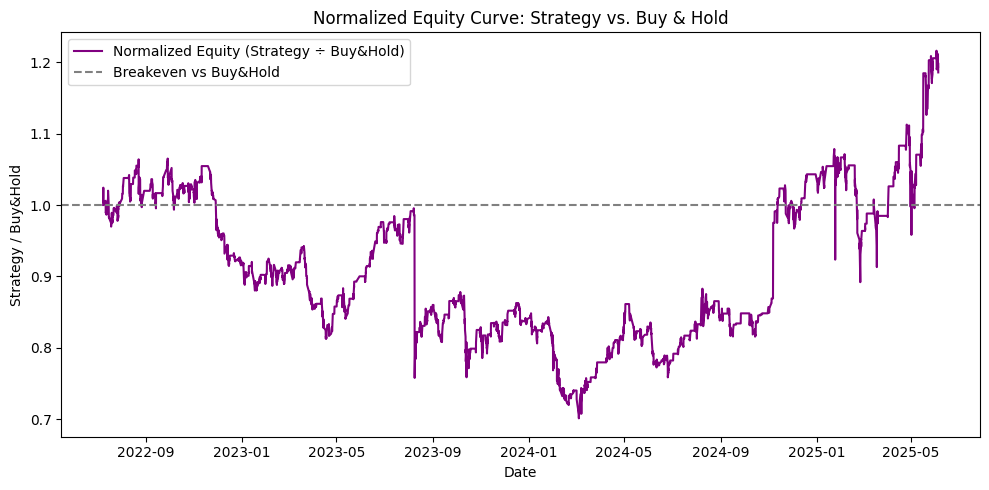

Final normalized ratio (strategy ÷ buy&hold): 1.1856


In [110]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Define SMA + HMA functions (same as before)
def simple_moving_average(series: np.ndarray, period: int) -> np.ndarray:
    sma = np.full_like(series, fill_value=np.nan, dtype=float)
    cumsum = np.cumsum(series, dtype=float)
    sma[period-1 :] = (
        (cumsum[period-1 :] 
         - np.concatenate(([0.0], cumsum[:-period]))
        )
        / period
    )
    return sma

def weighted_moving_average(series: np.ndarray, period: int) -> np.ndarray:
    w = np.arange(1, period + 1)
    w_sum = w.sum()
    out = np.full_like(series, fill_value=np.nan, dtype=float)
    for t in range(period - 1, len(series)):
        window = series[t - (period - 1) : t + 1]
        out[t] = (window * w).sum() / w_sum
    return out

def hull_moving_average(series: np.ndarray, length: int) -> np.ndarray:
    half_len = int(np.floor(length / 2))
    sqrt_len = int(np.floor(np.sqrt(length)))
    wma_full = weighted_moving_average(series, length)
    wma_half = weighted_moving_average(series, half_len)
    diff = 2 * wma_half - wma_full
    hma = weighted_moving_average(diff, sqrt_len)
    return hma

# Backtest function (SMA/HMA strategy)
def backtest_sma_hma_strategy(
    prices: np.ndarray,
    dates: np.ndarray,
    lookback: int = 30,
    short_threshold: float = 0.05,
):
    n = len(prices)
    sma = simple_moving_average(prices, lookback)
    hma = hull_moving_average(prices, lookback)
    
    positions = np.zeros(n, dtype=int)   # 0=flat, +1=long, -1=short
    equity = np.zeros(n, dtype=float)
    
    entry_indices = []
    exit_indices = []
    trade_returns = []
    
    last_equity = 1.0
    pos_flag = 0
    entry_price = np.nan
    entry_equity = np.nan
    
    for t in range(n):
        price = prices[t]
        
        # Exit logic
        if pos_flag == +1:
            if (not np.isnan(sma[t])) and price >= sma[t]:
                final_equity = entry_equity * (price / entry_price)
                trade_returns.append((price / entry_price) - 1.0)
                last_equity = final_equity
                pos_flag = 0
                exit_indices.append(t)
        elif pos_flag == -1:
            if (not np.isnan(hma[t])) and price <= hma[t]:
                final_equity = entry_equity * (2.0 - (price / entry_price))
                trade_returns.append((entry_price - price) / entry_price)
                last_equity = final_equity
                pos_flag = 0
                exit_indices.append(t)
        
        # Mark-to-market equity
        if pos_flag == 0:
            equity[t] = last_equity
        elif pos_flag == +1:
            equity[t] = entry_equity * (price / entry_price)
        else:
            equity[t] = entry_equity * (2.0 - (price / entry_price))
        
        # Entry logic
        if pos_flag == 0:
            if (not np.isnan(sma[t])) and (price < sma[t]):
                pos_flag = +1
                entry_price = price
                entry_equity = equity[t]
                entry_indices.append(t)
            elif (not np.isnan(sma[t])) and (price > sma[t] * (1.0 + short_threshold)):
                pos_flag = -1
                entry_price = price
                entry_equity = equity[t]
                entry_indices.append(t)
        
        positions[t] = pos_flag
    
    # Force exit at final bar if still in position
    if pos_flag == +1:
        price = prices[-1]
        final_equity = entry_equity * (price / entry_price)
        trade_returns.append((price / entry_price) - 1.0)
        last_equity = final_equity
        exit_indices.append(n - 1)
        positions[-1] = 0
        equity[-1] = last_equity
    elif pos_flag == -1:
        price = prices[-1]
        final_equity = entry_equity * (2.0 - (price / entry_price))
        trade_returns.append((entry_price - price) / entry_price)
        last_equity = final_equity
        exit_indices.append(n - 1)
        positions[-1] = 0
        equity[-1] = last_equity
    
    final_equity = last_equity
    total_return = final_equity - 1.0
    num_trades = len(trade_returns)
    wins = sum(1 for r in trade_returns if r > 0)
    win_rate = wins / num_trades if num_trades > 0 else np.nan
    
    hours_per_year = 252 * 6.5
    cagr = (final_equity) ** (hours_per_year / n) - 1.0
    
    metrics = {
        "total_return": total_return,
        "num_trades": num_trades,
        "win_rate": win_rate,
        "approx_CAGR": cagr,
    }
    
    return {
        "sma": sma,
        "hma": hma,
        "positions": positions,
        "entry_indices": entry_indices,
        "exit_indices": exit_indices,
        "equity_curve": equity,
        "trade_returns": trade_returns,
        "metrics": metrics,
    }

# 1) Download data
ticker = "NOVO-B.CO"
data = yf.download(
    ticker,
    period="730d",
    interval="1h",
    auto_adjust=False,
    progress=False,
)
prices_raw = data["Adj Close"].values.astype(float).flatten()
dates = data.index.to_numpy()
price_novo2 = prices_raw.copy()

# 2) Run the backtest
result = backtest_sma_hma_strategy(
    prices=price_novo2,
    dates=dates,
    lookback=30,
    short_threshold=0.05,
)

# 3) Compute buy-and-hold equity curve
buy_hold_equity = prices_raw / prices_raw[0]

# 4) Normalize strategy equity by buy-and-hold equity
strategy_equity = result["equity_curve"]
normalized_equity = strategy_equity / buy_hold_equity

# 5) Plot normalized equity
plt.figure(figsize=(10, 5))
plt.plot(dates, normalized_equity, label="Normalized Equity (Strategy ÷ Buy&Hold)", color="purple")
plt.axhline(1.0, color="gray", linestyle="--", label="Breakeven vs Buy&Hold")
plt.title("Normalized Equity Curve: Strategy vs. Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Strategy / Buy&Hold")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 6) Print final normalized ratio
final_ratio = normalized_equity[-1]
print(f"Final normalized ratio (strategy ÷ buy&hold): {final_ratio:.4f}")


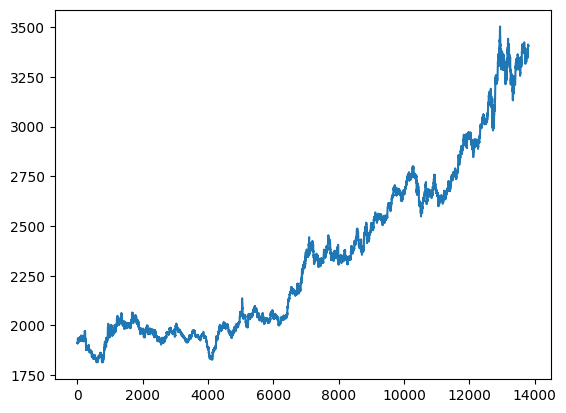

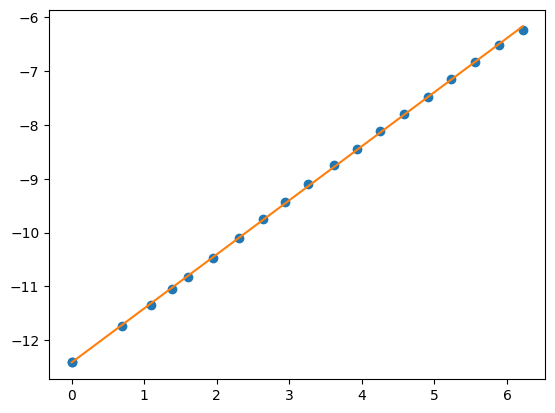

0.5019362812122893


In [18]:
# 1. Define the ticker
ticker = "GC=F"    # Novo Nordisk B (Copenhagen Stock Exchange) :contentReference[oaicite:1]{index=1}

# 2. Download max-period history
data = yf.download(
    ticker,
    period="730d",       # up to 730 days back is supported for interval="1h"
    interval="1h",       # fetch 1-hour bars
    auto_adjust=False,   # ensure “Close” = actual settlement price
    progress=False
)

# 3. Extract adjusted close prices
prices = data["Adj Close"]   # split/dividend-adjusted closing price

# 4. Convert to NumPy array
price_gold = prices.values
plt.plot(price_gold[:])
plt.show()
# 5. (Optional) Get corresponding dates
dates = data.index.to_numpy()

start = np.log(1)  
end = np.log(500)
TL = np.round( np.logspace(start, end, num=20, base = np.exp(1)),0).astype(int)

Hurst_temp = np.zeros(len(TL))

for i, p in enumerate(TL):
    Hurst_temp[i] = Hurst(price_gold[:],p)

log_TL = np.log(TL)
log_Temp2 = np.log(Hurst_temp)
# Perform linear regression (1st-degree polynomial fit)
slope, intercept = np.polyfit(log_TL, log_Temp2, 1)
x = np.linspace(log_TL[0],log_TL[-1],1000)
y = slope*x + intercept
plt.plot(log_TL, log_Temp2, 'o')
plt.plot(x,y)
plt.show()
print(slope/2)

BRK-B: using Adj Close
^GSPC: using Adj Close
GC=F: using Adj Close
^DJI: using Adj Close
SI=F: using Adj Close
CL=F: using Adj Close
NOVO-B.CO: using Adj Close
BTC-USD: using Adj Close
MAERSK-B.CO: using Adj Close
ETH-USD: using Adj Close
^IXIC: using Adj Close
EEM: using Adj Close


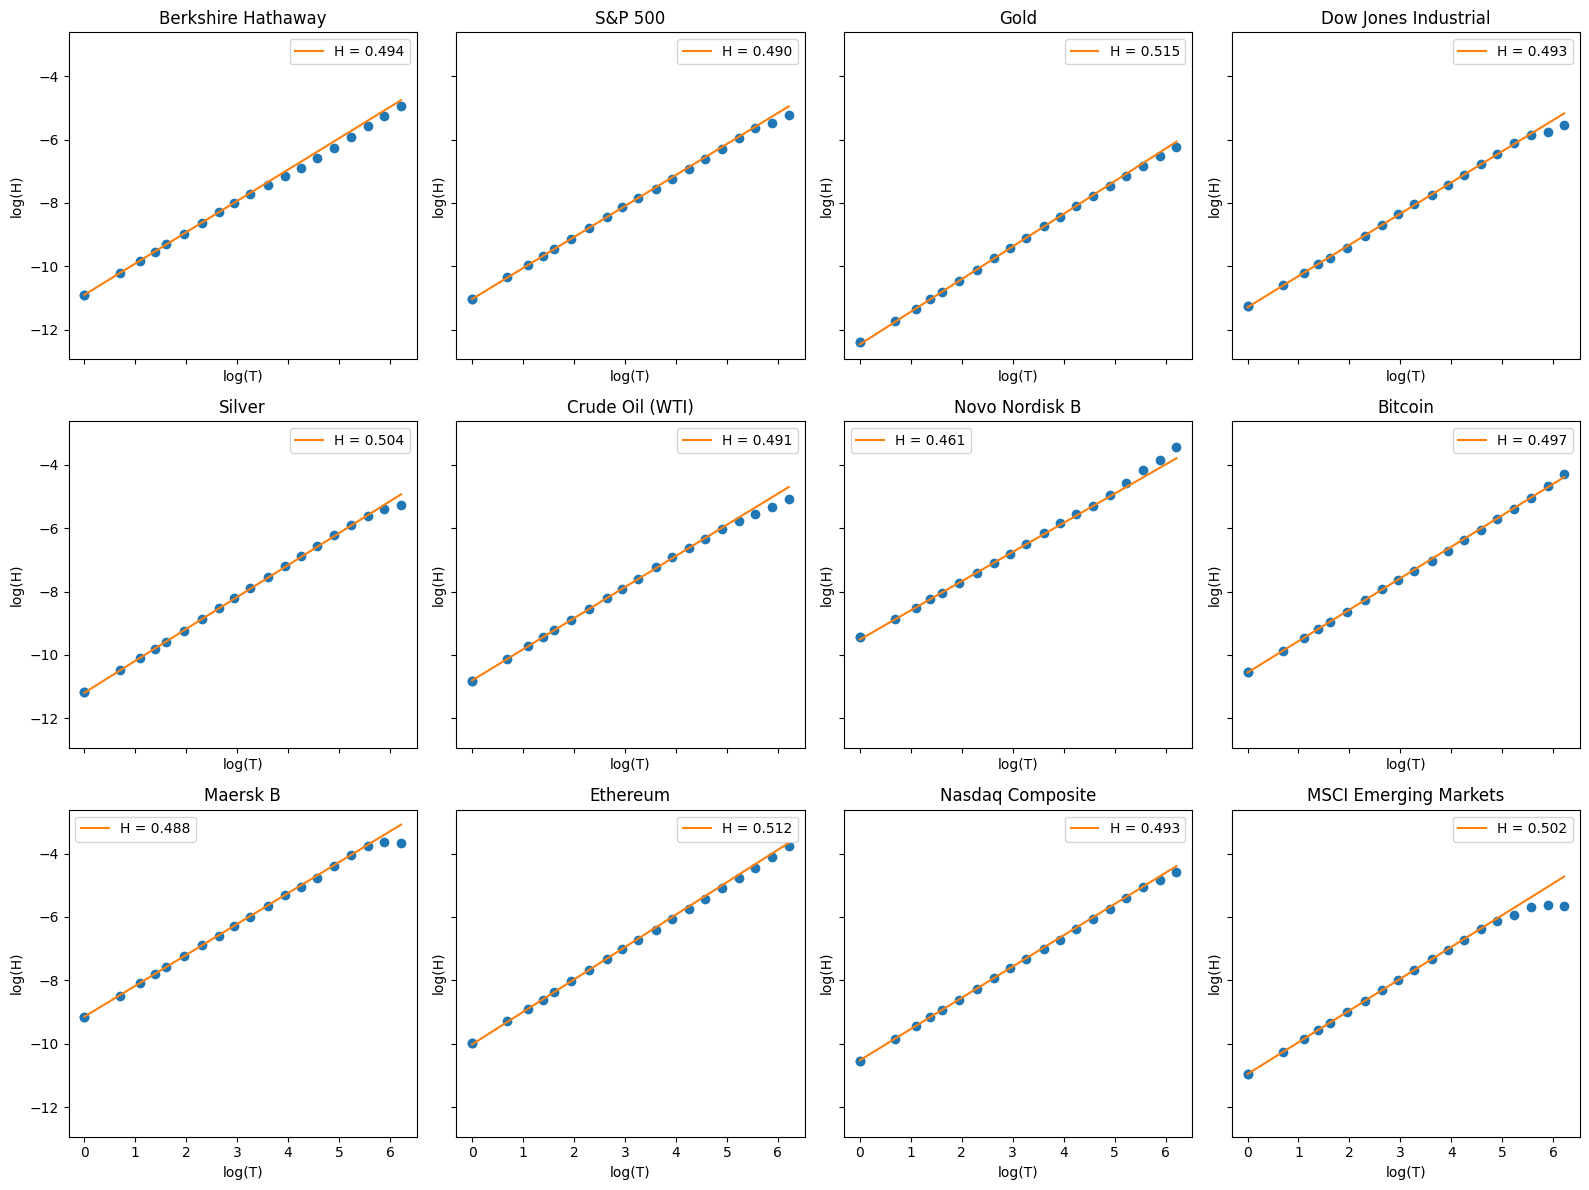

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Expanded Tickers
tickers = {
    # Old–greed driven (left half columns)
    'Berkshire Hathaway':        'BRK-B',
    'S&P 500':                   '^GSPC',
    'Gold':                      'GC=F',
    'Dow Jones Industrial':      '^DJI',
    'Silver':                    'SI=F',
    'Crude Oil (WTI)':           'CL=F',

    # Newer need–driven (right half columns)
    'Novo Nordisk B':            'NOVO-B.CO',
    'Bitcoin':                   'BTC-USD',
    'Maersk B':                  'MAERSK-B.CO',
    'Ethereum':                  'ETH-USD',
    'Nasdaq Composite':          '^IXIC',
    'MSCI Emerging Markets':     'EEM',
    # (Optional) add U.S. 10-Year Yield if you like, e.g. '^TNX'
}

# 2. Download daily data for last 5 years (1825 days)
data = yf.download(
    tickers=list(tickers.values()),
    period='730d',
    interval='1h',
    auto_adjust=False,   # “Close” = actual settlement price
    progress=False
)

# 3. Build flat price DataFrame: preferring Adj Close per symbol
prices = pd.DataFrame(index=data.index)
for name, sym in tickers.items():
    if ('Adj Close', sym) in data.columns:
        prices[name] = data['Adj Close', sym]
        print(f"{sym}: using Adj Close")
    else:
        prices[name] = data['Close', sym]
        print(f"{sym}: using Close")

# 4. daily averages are just the daily series
daily_avg = prices.copy()

# 5. Hurst windowed estimator
def Hurst(series, window):
    diffs = (np.log(series[window:]) - np.log(series[:-window]))**2
    return diffs.mean()

# 6. Window sizes (1 ≤ T ≤ 1000, log-spaced)
start, end = np.log(1), np.log(500)
TL = np.round(np.logspace(start, end, num=20, base=np.e)).astype(int)

# 7. Compute Hurst exponents for each market
results = {}
for name in daily_avg.columns:
    series = daily_avg[name].dropna().values
    H_vals = np.array([Hurst(series, w) for w in TL])
    log_T, log_H = np.log(TL), np.log(H_vals)
    # Fit skipping the very small windows if noisy
    slope, intercept = np.polyfit(log_T[2:10], log_H[2:10], 1)
    results[name] = {
        'log_T': log_T,
        'log_H': log_H,
        'slope': slope,
        'intercept': intercept,
        'H': slope / 2
    }

# 8. Plot a 3×4 grid
n = len(results)
cols = 4
rows = int(np.ceil(n/cols))

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    x_fit = np.linspace(r['log_T'].min(), r['log_T'].max(), 100)
    y_fit = r['slope']*x_fit + r['intercept']
    ax.plot(r['log_T'], r['log_H'], 'o')
    ax.plot(x_fit, y_fit, '-', label=f"H = {r['H']:.3f}")
    ax.set_title(name)
    ax.set_xlabel('log(T)')
    ax.set_ylabel('log(H)')
    ax.legend()

# Turn off any unused subplots
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()
